In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
FILE_PATH = Path.cwd().parent / "datasets" / "zoo.csv"

In [3]:
df = pd.read_csv(FILE_PATH)

In [4]:
df.shape

(101, 18)

In [5]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [7]:
df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


In [ ]:
df.nunique() # Take a quick look at the number of unique columns in each

animal_name    100
hair             2
feathers         2
eggs             2
milk             2
airborne         2
aquatic          2
predator         2
toothed          2
backbone         2
breathes         2
venomous         2
fins             2
legs             6
tail             2
domestic         2
catsize          2
class_type       7
dtype: int64

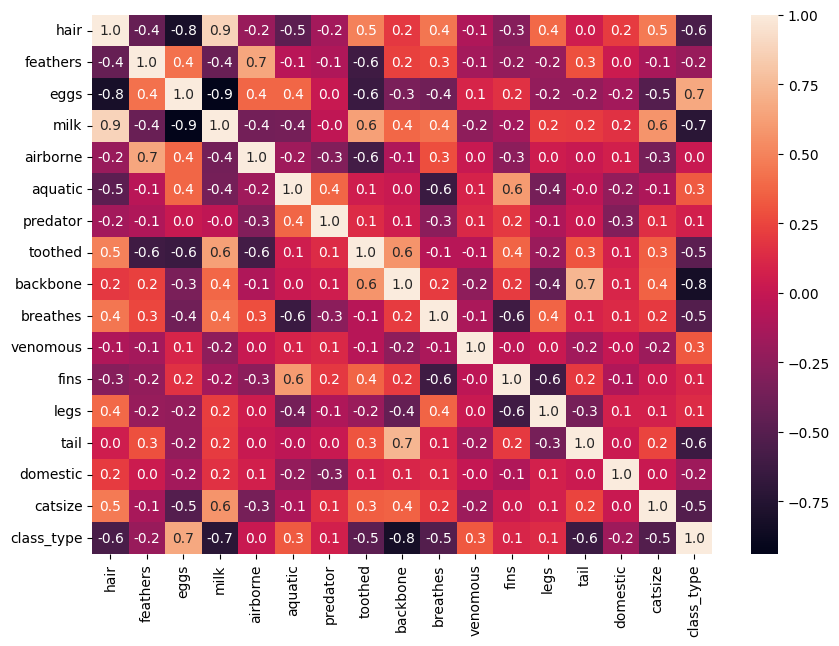

In [21]:
plt.figure(figsize=(10,7))
sns.heatmap(data=df.corr(numeric_only=True),annot=True,fmt='.1f')
plt.show()
# We literally have a mesh of correlations here 

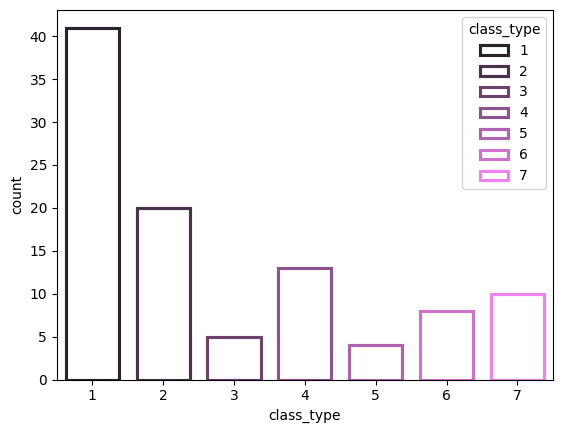

In [11]:
# The number of classes in the output column we have to predicted 
# As we can look clearly the the classes are imbalanced
sns.countplot(data = df , x = 'class_type', hue = 'class_type', palette = 'dark:violet' , stat='count' , width=0.75 , saturation=1 , fill = False)
plt.show()

In [23]:
X = df.drop(columns = ['animal_name' , 'class_type'])
y = df['class_type']

In [29]:
X_train , X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 42,stratify=y)

In [30]:
lor = LogisticRegression(max_iter=5000)
lor.fit(X_train,y_train)
y_pred_lor = lor.predict(X_test)
print(f'Cross Val Score : {cross_val_score(lor,X,y,cv=4).mean()}')

Cross Val Score : 0.9303846153846154


In [32]:
# Now let's try Decision Tree Classifier to search for any improvement

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [62]:
clf = DecisionTreeClassifier(criterion='entropy',splitter='random')
clf.fit(X_train,y_train)
y_pred_clf = clf.predict(X_test)
print(f'Cross Val Score : {cross_val_score(clf,X,y,cv=4).mean()}')

Cross Val Score : 0.9303846153846154


In [17]:
for x in ['gini', 'entropy', 'log_loss']:
    clf = DecisionTreeClassifier(criterion='entropy',splitter='random')
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    print(f'Cross Val Score : {cross_val_score(clf,X,y,cv=4).mean()}')

Cross Val Score : 0.9203846153846154
Cross Val Score : 0.9403846153846154
Cross Val Score : 0.9403846153846154


In [76]:
y_pred_lor = pd.DataFrame(lor.predict(X),columns=['y_pred_lor'])
y_pred_clf = pd.DataFrame(clf.predict(X),columns=['y_pred_clf'])

In [77]:
y_pred_lor.shape,y.shape,y_pred_clf.shape

((101, 1), (101,), (101, 1))

In [78]:
df1 = pd.concat([df,y_pred_lor,y_pred_clf],axis=1)

In [79]:
df1

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type,y_pred_lor,y_pred_clf
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4,4,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,1,1,1,1
97,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0,6,6,6
98,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1,1,1
99,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,7,7,7


<Axes: xlabel='class_type', ylabel='Count'>

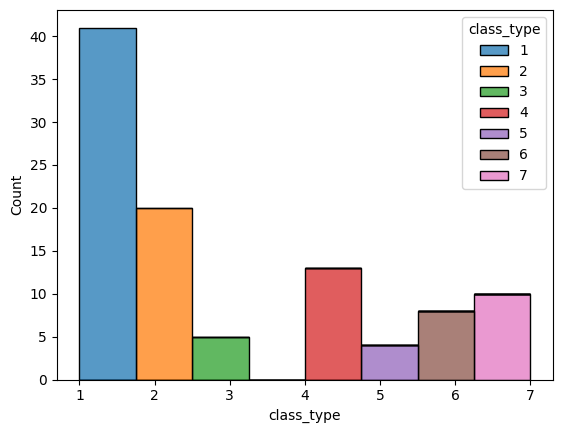

In [110]:
sns.histplot( data = df1 , x = 'class_type' ,palette = 'tab10' , hue = 'class_type' , multiple = 'stack' )

<Axes: xlabel='class_type', ylabel='Count'>

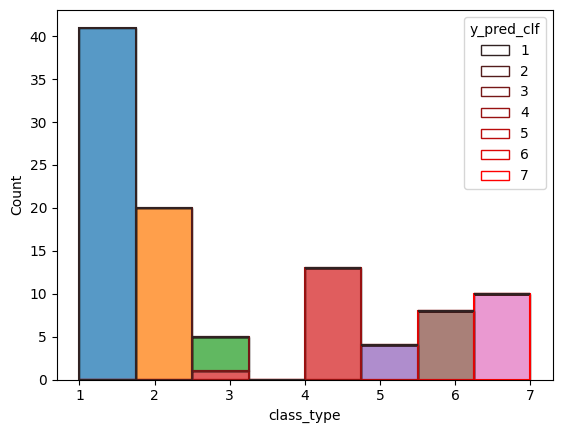

In [123]:
sns.histplot( data = df1 , x = 'class_type' ,palette = 'tab10' , hue = 'y_pred_lor' , multiple = 'stack' , legend = True )
sns.histplot( data = df1 , x = 'class_type' ,palette = 'dark:red' , hue = 'y_pred_clf' , multiple = 'stack' , fill = False , element='bars')

<Axes: xlabel='class_type', ylabel='Count'>

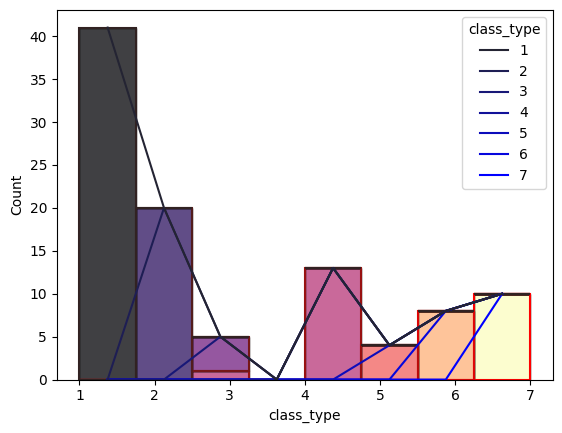

In [127]:
sns.histplot( data = df1 , x = 'class_type' ,palette = 'magma' , hue = 'y_pred_lor' , multiple = 'stack' , legend = True )
sns.histplot( data = df1 , x = 'class_type' ,palette = 'dark:red' , hue = 'y_pred_clf' , multiple = 'stack' , fill = False , element='bars')
sns.histplot( data = df1 , x = 'class_type' ,palette = 'dark:blue' , hue = 'class_type' , multiple = 'stack' , fill = False , element='poly' )

In [135]:
accuracy_score(y_test,lor.predict(X_test)),accuracy_score(y_test,clf.predict(X_test))

(0.9523809523809523, 0.9523809523809523)

In [142]:
pd.DataFrame(confusion_matrix(y_test,lor.predict(X_test)))

,0,1,2,3,4,5
0,12,0,0,0,0,0
1,0,2,0,0,0,0
2,0,0,0,1,0,0
3,0,0,0,2,0,0
4,0,0,0,0,3,0
5,0,0,0,0,0,1


In [143]:
pd.DataFrame(confusion_matrix(y_test,clf.predict(X_test)))

,0,1,2,3,4,5
0,12,0,0,0,0,0
1,0,2,0,0,0,0
2,0,0,0,1,0,0
3,0,0,0,2,0,0
4,0,0,0,0,3,0
5,0,0,0,0,0,1


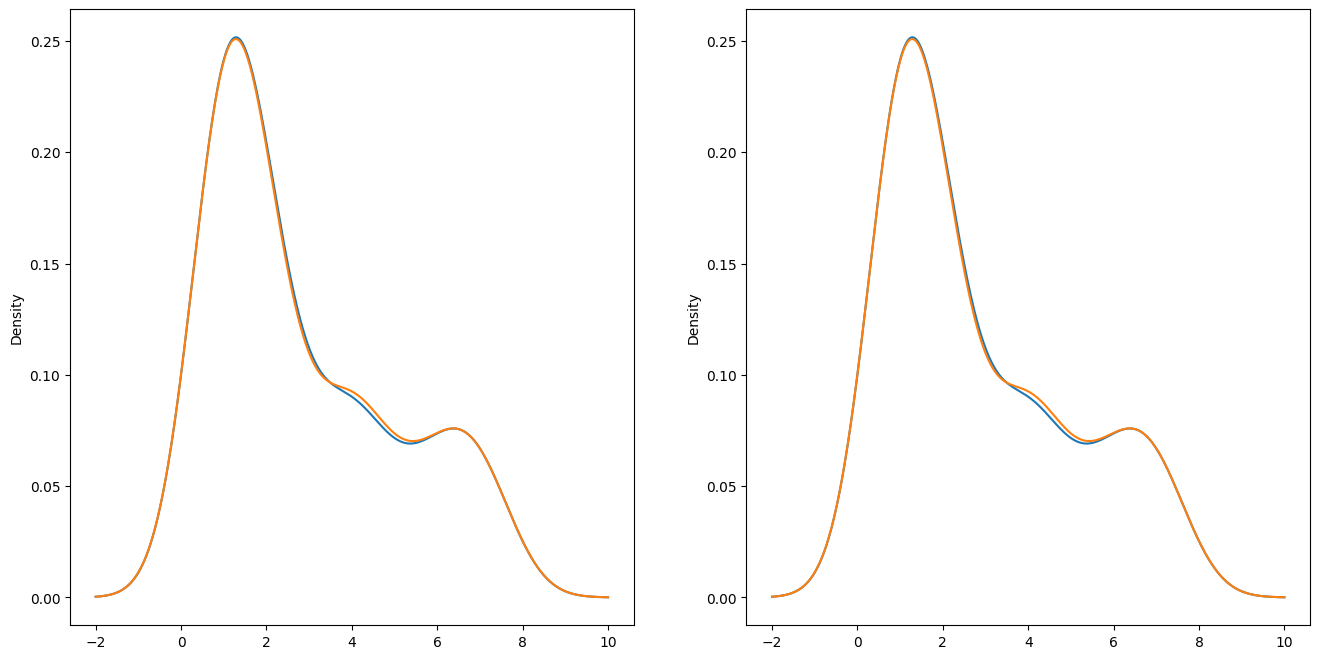

In [177]:
plt.figure(figsize=(16,8))
plt.subplot(121)
df1['class_type'].plot(kind='kde')
df1['y_pred_lor'].plot(kind='kde')
plt.subplot(122)
df1['class_type'].plot(kind='kde')
df1['y_pred_clf'].plot(kind='kde')
plt.show()